# Phase 1 — Exploratory Data Analysis (EDA)

**Goal:** understand the raw NYC Yellow-Taxi data well enough to *justify every decision* we make later. Three questions drive this notebook:

1. **Is demand cyclical in time?**  (If yes → time features like hour & weekday will predict well.)
2. **Is demand concentrated in space?**  (If yes → splitting the city into zones makes sense.)
3. **What bad data must we remove?**  (Outlier bounds for the cleaning step.)

> Data: NYC Yellow Taxi trips, **Jan–Mar 2016**. We work on a **2% random sample (~690k rows)** drawn across all three months so it is representative but fast.

## 0. Setup
Imports, plot style, and a helper that locates the project root so file paths work no matter where the notebook runs from.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

def find_root(start=Path.cwd()):
    # walk up until we find the folder that contains params.yaml
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above " + str(start))

ROOT = find_root()
FIGDIR = ROOT / "reports" / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)
params = yaml.safe_load(open(ROOT / "params.yaml"))

FRAC  = 0.02                    # the sampling fraction we used
SCALE = int(round(1 / FRAC))    # x50: turns sample counts into est. city-wide counts
print("Project root:", ROOT)
print("Scale factor (1/frac):", SCALE)

Project root: /run/media/dhruv/New Volume/final_projects/uber_prediction/nyc-taxi-demand-prediction
Scale factor (1/frac): 50


## 1. Load a representative sample

The raw data is ~7 GB across three monthly CSVs — too big to load whole comfortably. So we use **Dask** (an out-of-core, parallel cousin of pandas) to read all three files and draw a **2% random sample** spanning the full quarter, then **cache it to Parquet**.

*Interview angle:* reading 34M+ rows once to sample, then caching, makes every re-run of this analysis instant — *"expensive read once, iterate fast."* The cache lives in `data/interim/` (gitignored).

In [2]:
import dask.dataframe as dd

CACHE = ROOT / "data" / "interim" / "eda_sample.parquet"
COLS = ["tpep_pickup_datetime", "passenger_count", "trip_distance",
        "pickup_longitude", "pickup_latitude", "fare_amount", "total_amount"]

if CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f"Loaded cached sample: {len(df):,} rows")
else:
    files = [str(Path(params["paths"]["raw_data_dir"]) / f) for f in params["data_files"]]
    ddf = dd.read_csv(files, usecols=COLS,
                      dtype={c: "float64" for c in COLS if c != "tpep_pickup_datetime"})
    df = ddf.sample(frac=FRAC, random_state=params["sample"]["random_state"]).compute()
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE, index=False)
    print(f"Built and cached sample: {len(df):,} rows")

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df.head()

Loaded cached sample: 690,001 rows


,tpep_pickup_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,fare_amount,total_amount
0,2016-01-01 16:03:27,1.0,1.20,-73.996506,40.753212,5.5,6.30
1,2016-01-01 18:00:08,3.0,6.20,-73.979492,40.759418,22.5,23.30
2,2016-01-01 00:59:50,1.0,0.80,-73.954369,40.774372,5.0,7.55
3,2016-01-01 01:52:44,5.0,8.43,-73.983086,40.741764,26.0,30.30
4,2016-01-01 05:02:28,4.0,11.40,-73.987244,40.724743,36.5,49.10


## 2. First look — shape, types, missing values
Before any charts, sanity-check the raw material.

In [3]:
print("shape:", df.shape)
print("\ndtypes:")
print(df.dtypes)
print("\nmissing (NaN) per column:")
print(df.isna().sum())
df.describe().round(2)

shape: (690001, 7)

dtypes:
tpep_pickup_datetime    datetime64[ns]
passenger_count                float64
trip_distance                  float64
pickup_longitude               float64
pickup_latitude                float64
fare_amount                    float64
total_amount                   float64
dtype: object

missing (NaN) per column:
tpep_pickup_datetime    0
passenger_count         0
trip_distance           0
pickup_longitude        0
pickup_latitude         0
fare_amount             0
total_amount            0
dtype: int64


,tpep_pickup_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,fare_amount,total_amount
count,690001,690001.00,690001.00,690001.00,690001.00,690001.00,690001.00
mean,2016-02-16 16:28:39.141803776,1.66,5.49,-72.83,40.12,12.55,15.76
min,2016-01-01 00:00:40,0.00,0.00,-80.42,0.00,-160.00,-160.30
25%,2016-01-26 00:37:48,1.00,1.00,-73.99,40.74,6.50,8.30
50%,2016-02-17 11:44:28,1.00,1.70,-73.98,40.75,9.00,11.76
75%,2016-03-10 00:21:43,2.00,3.10,-73.97,40.77,14.00,17.30
max,2016-03-31 23:59:49,9.00,1653402.00,0.00,44.26,2020.37,2021.17
std,NaN,1.31,1996.71,9.11,5.02,11.12,13.64


**Read the `describe()` table carefully — this is where the story starts:**

- There are **no `NaN`s**, yet the data is clearly dirty: `fare_amount` runs from **−160 to 2,020**, `trip_distance` maxes at **~1.6 million miles**, and the coordinate columns include **0.0**. The "missing" data is hidden as *impossible values*, not blanks.
- But the **25–75% coordinate range** (lon ≈ −73.99…−73.97, lat ≈ 40.74…40.77) is exactly **Manhattan** — so the *typical* row is fine; only the tails are broken.

We quantify and remove these in §6 (they feed the Phase-2 cleaning step).

## 3. ⭐ The key chart — demand by hour-of-day and weekday

This is the single most important plot in the project. Every raw row is one pickup with a valid timestamp, so we can count pickups by time **without any cleaning**. We compute the **average pickups per hour for each weekday** (scaled ×50 to estimate city-wide totals from our 2% sample).

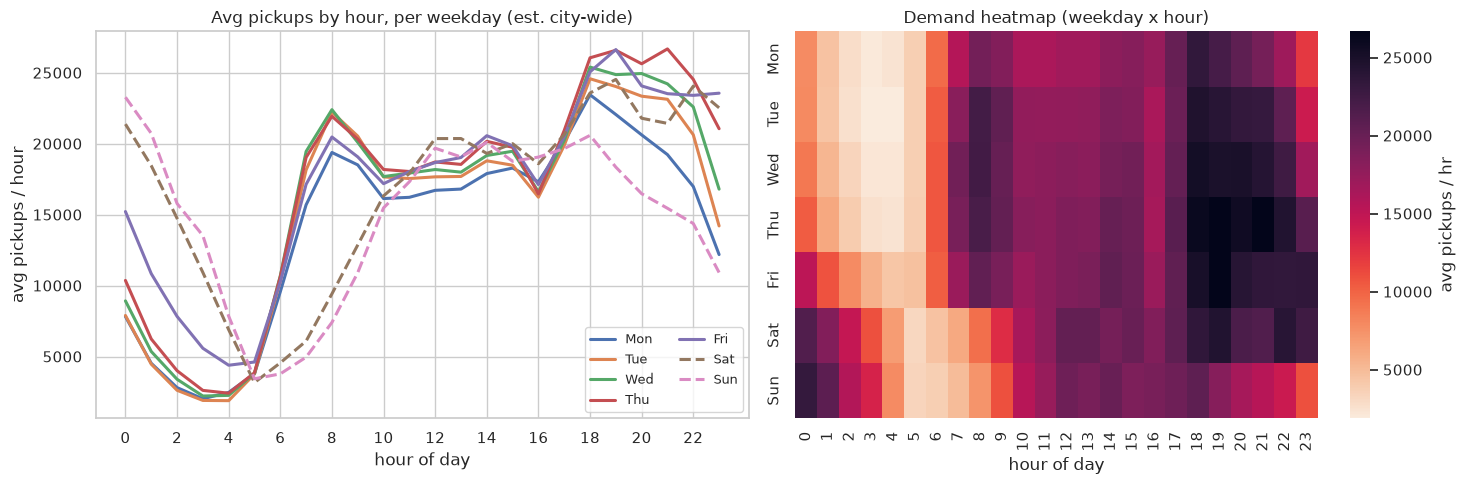

In [4]:
df["date"] = df["tpep_pickup_datetime"].dt.date
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["dow"]  = df["tpep_pickup_datetime"].dt.dayofweek     # 0=Mon ... 6=Sun

# pickups per (date, hour), then average across the ~13 dates of each weekday
per_date_hour = df.groupby(["date", "dow", "hour"]).size().rename("pickups").reset_index()
profile = (per_date_hour.groupby(["dow", "hour"])["pickups"].mean() * SCALE).reset_index()

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for d in range(7):
    sub = profile[profile["dow"] == d]
    ax1.plot(sub["hour"], sub["pickups"], lw=2.2,
             ls="-" if d < 5 else "--", label=days[d])
ax1.set(title="Avg pickups by hour, per weekday (est. city-wide)",
        xlabel="hour of day", ylabel="avg pickups / hour")
ax1.set_xticks(range(0, 24, 2))
ax1.legend(ncol=2, fontsize=9)

pivot = profile.pivot(index="dow", columns="hour", values="pickups")
pivot.index = days
sns.heatmap(pivot, cmap="rocket_r", ax=ax2, cbar_kws={"label": "avg pickups / hr"})
ax2.set(title="Demand heatmap (weekday x hour)", xlabel="hour of day", ylabel="")

plt.tight_layout()
plt.savefig(FIGDIR / "demand_by_hour_dow.png", dpi=120, bbox_inches="tight")
plt.show()

**What this shows:**

- **Weekdays (solid lines)** have a **twin-peak** shape: a **morning rush (~8 am)** and a bigger **evening rush (~6–7 pm)** — classic commuting.
- **Weekends (dashed)** are different: quiet mornings, but demand **stays high past midnight** (nightlife, not commuting).
- Peak demand is several times the ~4–5 am trough.

**Why it matters for modeling:** demand depends strongly on **hour of day** *and* **weekday**. The reference project used the weekday but **not the hour of day** — missing the strongest signal. Adding **hour (cyclically encoded)** is our **upgrade #1**.

## 4. Demand over time (the whole quarter)
Daily totals reveal the weekly rhythm and any anomalies.

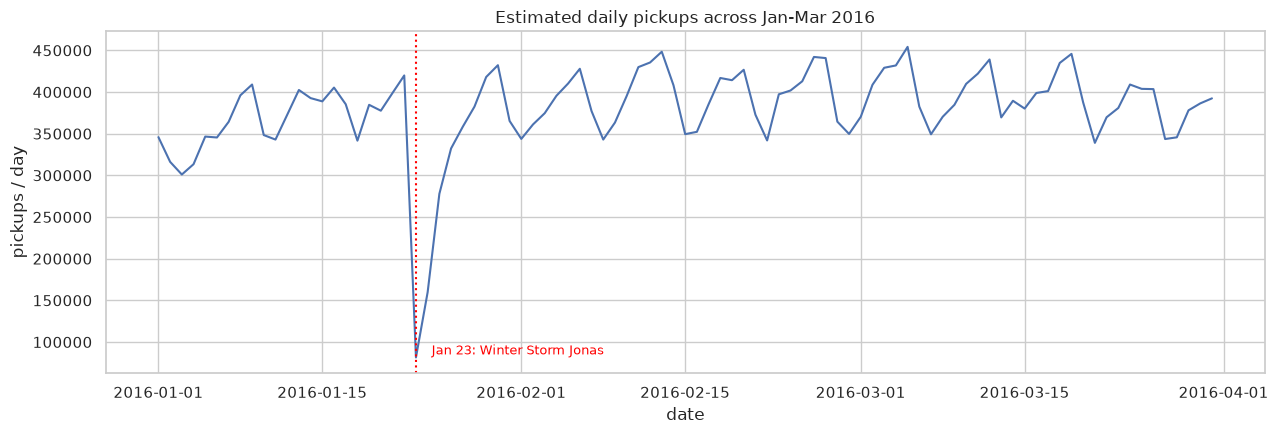

In [5]:
daily = df.groupby("date").size() * SCALE
daily.index = pd.to_datetime(daily.index)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily.values, lw=1.5)
ax.axvline(pd.Timestamp("2016-01-23"), color="red", ls=":", lw=1.5)
ax.text(pd.Timestamp("2016-01-24"), daily.min(), " Jan 23: Winter Storm Jonas",
        color="red", va="bottom", fontsize=9)
ax.set(title="Estimated daily pickups across Jan-Mar 2016",
       xlabel="date", ylabel="pickups / day")
plt.tight_layout()
plt.savefig(FIGDIR / "demand_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

**What this shows:** a steady **weekly cycle** (weekday peaks, Sunday troughs) and a **sharp crash on ~Jan 23, 2016** — **Winter Storm Jonas**, when NYC imposed a travel ban. Pointing out a real-world anomaly like this is a nice interview note: the model learns *normal* rhythm, not black-swan events.

## 5. Where does demand happen? (spatial concentration)
Plot pickup coordinates (zoomed to NYC). Faint points pile up where demand is dense.

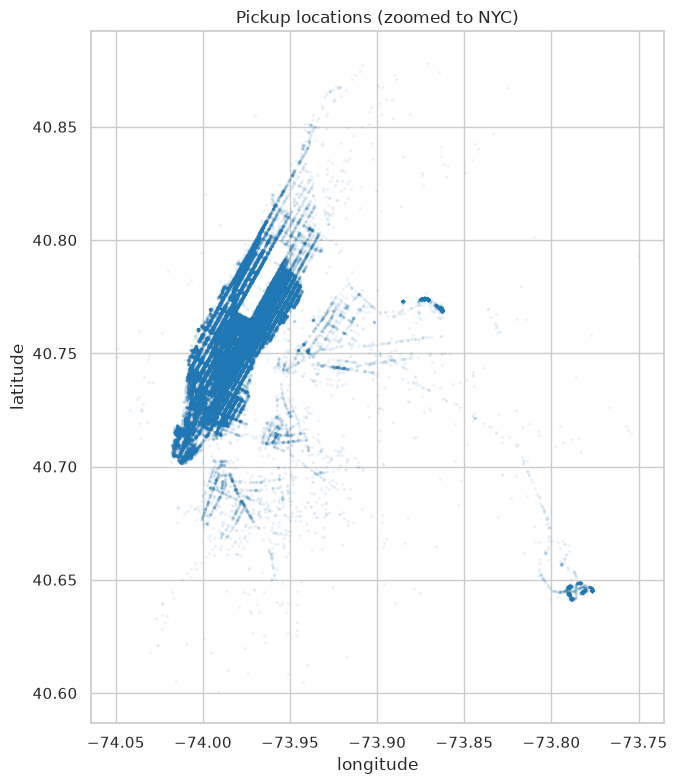

11,057 of 690,001 sampled points (1.6%) fall OUTSIDE this NYC box (0,0 GPS errors / far-flung points).


In [6]:
box = dict(lon=(-74.05, -73.75), lat=(40.60, 40.88))
m = (df["pickup_longitude"].between(*box["lon"]) &
     df["pickup_latitude"].between(*box["lat"]))
pts = df.loc[m, ["pickup_longitude", "pickup_latitude"]].sample(
    min(120000, int(m.sum())), random_state=1)

fig, ax = plt.subplots(figsize=(7.5, 8))
ax.scatter(pts["pickup_longitude"], pts["pickup_latitude"], s=2, alpha=0.05, color="#1f77b4")
ax.set(title="Pickup locations (zoomed to NYC)", xlabel="longitude", ylabel="latitude")
ax.set_aspect(1.3)
plt.tight_layout()
plt.savefig(FIGDIR / "pickup_locations.png", dpi=120, bbox_inches="tight")
plt.show()

outside = int((~m).sum())
print(f"{outside:,} of {len(df):,} sampled points ({100*outside/len(df):.1f}%) fall OUTSIDE "
      f"this NYC box (0,0 GPS errors / far-flung points).")

**What this shows:** pickups are overwhelmingly concentrated in **Manhattan**, with bright secondary clusters at **JFK** and **LaGuardia** airports. Demand is *not* uniform — which is exactly why we later **cluster pickups into 30 zones** and model each zone separately, rather than one city-wide number. The % printed above are the GPS errors we clean next.

## 6. Outliers — justifying the cleaning bounds
Exact counts of impossible rows, plus the cutoffs we will apply in Phase 2. Boxplots are clipped to the 99th percentile for readability — the titles note the true extremes.

0-coordinate rows : 10,631 (1.54%)
fare <= 0 rows    : 498 (0.07%)
distance <= 0 rows: 4,083 (0.59%)

fare_amount quantiles:
0.500       9.00
0.900      24.00
0.990      52.00
0.999      81.50
1.000    2020.37

trip_distance quantiles:
0.500          1.70
0.900          6.57
0.990         18.57
0.999         24.60
1.000    1653402.00


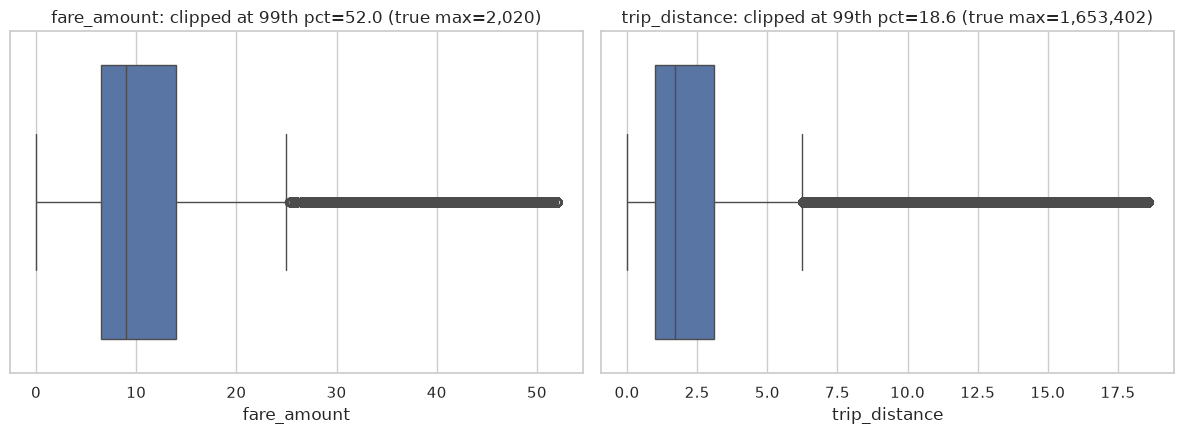

In [7]:
bad_coord = int(((df["pickup_longitude"] == 0) | (df["pickup_latitude"] == 0)).sum())
bad_fare  = int((df["fare_amount"] <= 0).sum())
bad_dist  = int((df["trip_distance"] <= 0).sum())
n = len(df)
print(f"0-coordinate rows : {bad_coord:,} ({100*bad_coord/n:.2f}%)")
print(f"fare <= 0 rows    : {bad_fare:,} ({100*bad_fare/n:.2f}%)")
print(f"distance <= 0 rows: {bad_dist:,} ({100*bad_dist/n:.2f}%)")
print("\nfare_amount quantiles:")
print(df["fare_amount"].quantile([.5, .9, .99, .999, 1]).round(2).to_string())
print("\ntrip_distance quantiles:")
print(df["trip_distance"].quantile([.5, .9, .99, .999, 1]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["fare_amount", "trip_distance"]):
    q99 = df[col].quantile(0.99)
    sns.boxplot(x=df[col].clip(lower=0, upper=q99), ax=ax, color="#4c72b0")
    ax.set(title=f"{col}: clipped at 99th pct={q99:.1f} (true max={df[col].max():,.0f})", xlabel=col)
plt.tight_layout()
plt.savefig(FIGDIR / "outliers_fare_distance.png", dpi=120, bbox_inches="tight")
plt.show()

**The cleaning rules we will apply in Phase 2** (`params.yaml` → `clean`):

| Rule | Why |
|---|---|
| keep pickups inside NYC bounding box (lon −74.15…−73.70, lat 40.55…40.95) | drops `0,0` "null-island" and far-flung GPS errors |
| `fare_amount` > 0 and ≤ ~99th pct | negative fares are refunds/errors; the huge tail is impossible |
| `trip_distance` > 0 and ≤ ~99th pct | 0-mile and million-mile trips are impossible |

Each filter has a *reason* — that is what an interviewer wants to hear, not just "I removed outliers."

## 7. Takeaways (the EDA story)

1. **Demand is cyclical in time** — strong hour-of-day and weekday patterns → we add **hour + cyclical time features** (upgrade #1).
2. **Demand is concentrated in space** — Manhattan + airports → we **cluster into 30 zones** and model each separately.
3. **The raw data has clear, explainable outliers** — impossible fares/distances and 0,0 GPS → percentile + bounding-box **cleaning** in Phase 2.

**One-line interview angle:** *"EDA showed demand is cyclical by time-of-day and spatially concentrated — that directly motivated the time features and the per-zone modeling, and it revealed the outliers I needed to clean."*